# 电商平台用户行为分析与 RFM 价值分层体系搭建
本项目严格遵循数据分析全流程规范，执行逻辑为：数据预处理→用户全景画像 EDA→用户行为深度分析→RFM 用户价值分层→消费行为影响因素分析→业务策略输出

## 数据预处理
数据预处理环节对原始数据集开展质量校验与清洗工作，通过数据探查、缺失与重复样本处理、异常值过滤、格式修正及衍生指标构建，得到高质量数据集，支撑后续探索性数据分析与用户分层建模。

In [5]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde
#设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [11]:
df = pd.read_csv('user_personalized_features.csv')

In [15]:
print("数据基本信息：")
print(df.info())
print("\n数据描述性统计：")
print(df.describe())

数据基本信息：
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   1000 non-null   int64
 1   User_ID                      1000 non-null   str  
 2   Age                          1000 non-null   int64
 3   Gender                       1000 non-null   str  
 4   Location                     1000 non-null   str  
 5   Income                       1000 non-null   int64
 6   Interests                    1000 non-null   str  
 7   Last_Login_Days_Ago          1000 non-null   int64
 8   Purchase_Frequency           1000 non-null   int64
 9   Average_Order_Value          1000 non-null   int64
 10  Total_Spending               1000 non-null   int64
 11  Product_Category_Preference  1000 non-null   str  
 12  Time_Spent_on_Site_Minutes   1000 non-null   int64
 13  Pages_Viewed                 1000 non-null   int64
 

对数据集进行缺失值、重复值检测，经统计，全部字段无缺失值，无重复样本，数据集完整性较好，仅执行去重处理，数据质量满足后续分析要求。


In [17]:
print("\n各字段缺失值数量：")
print(df.isnull().sum())
print("\n重复数据行数：", df.duplicated().sum())
df = df.drop_duplicates()


各字段缺失值数量：
Unnamed: 0                     0
User_ID                        0
Age                            0
Gender                         0
Location                       0
Income                         0
Interests                      0
Last_Login_Days_Ago            0
Purchase_Frequency             0
Average_Order_Value            0
Total_Spending                 0
Product_Category_Preference    0
Time_Spent_on_Site_Minutes     0
Pages_Viewed                   0
Newsletter_Subscription        0
dtype: int64

重复数据行数： 0


按照业务规则过滤年龄、消费相关异常值，重置行索引，经校验原始数据不存在违规异常样本，清洗后仍为 1000 行 15 列。

In [19]:
#剔除年龄异常、购买频率负数、消费金额负数的脏数据，得到干净数据集，并且重置行号，最后输出清洗后的样本规模。
df = df[(df['Age'] >= 18) & (df['Age'] <= 70)]  # 只保留18-70岁的合理用户
df = df[df['Purchase_Frequency'] >= 0]  # 购买频率不能为负
df = df[df['Total_Spending'] >= 0]  # 消费额不能为负
df = df.reset_index(drop=True)
print(f"\n清洗后数据量：{df.shape[0]}行，{df.shape[1]}列")


清洗后数据量：1000行，15列


## 用户全景画像分析EDA
通过多维度交叉分析，明确平台核心用户的群体特征，为精细化运营提供基础用户地图。

(1) 从性别分布可以看出平台男女用户数量大体均衡，男性占比略高，运营设计上应当兼顾两性用户的消费诉求。

(2) 平台用户主力集中于 36‑55 岁中年群体；18‑25 岁年轻用户占比较低，是平台用户增长的核心潜力缺口。

(3) 郊区用户数量最多，下沉市场（郊区 + 农村）合计占比超 65%，是平台主要用户基本盘。

(4) 运动、时尚、美食是平台用户排名前三的兴趣方向，可围绕这三类兴趣开展主题营销与商品联动推荐。

(5) 从用户产品品类偏好分布可以看出，服装类是用户最偏好的品类，电子产品紧随其后，健康美妆的用户偏好度相对最低，平台用户消费兴趣主要集中在服饰与数码两大板块。

(6) 各年龄段用户平均消费水平差距很小，中老年用户同样拥有较高消费实力，不存在明显的年龄消费壁垒。

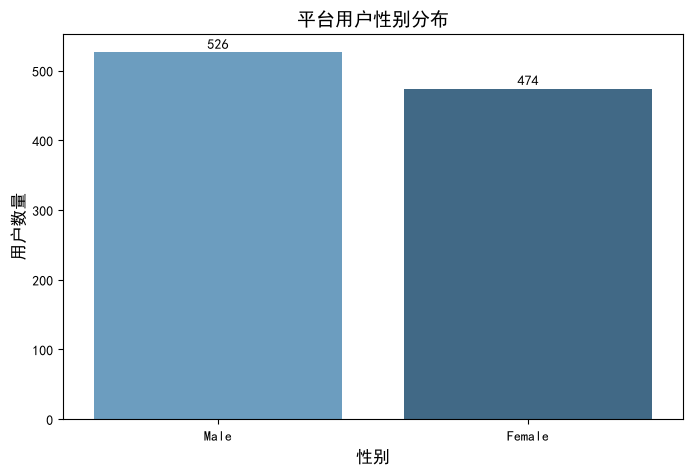

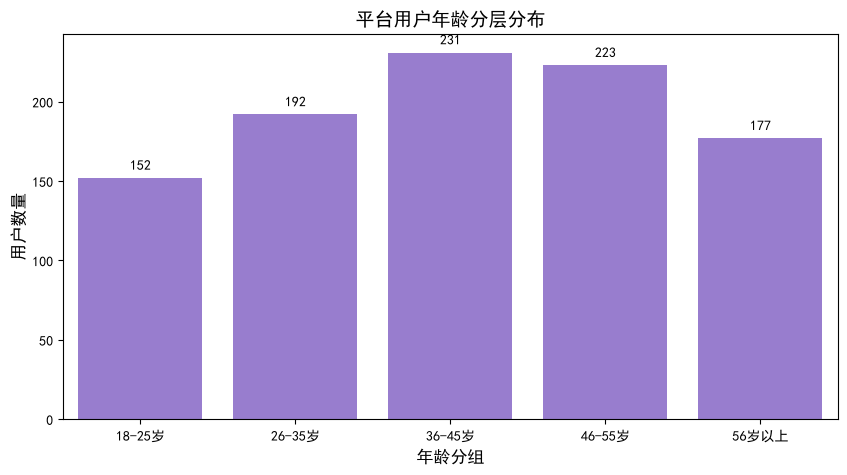

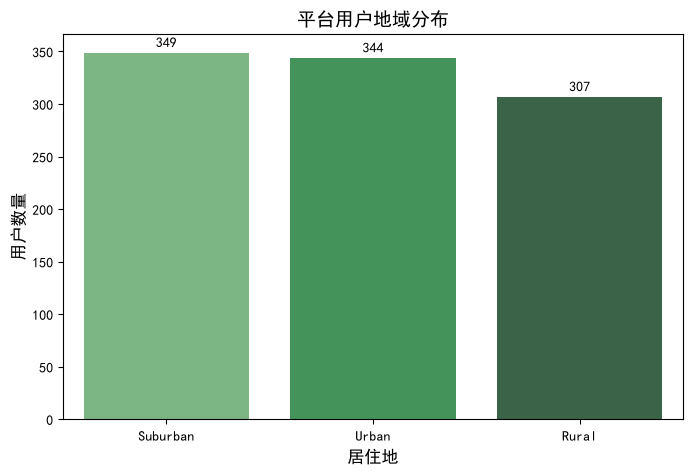

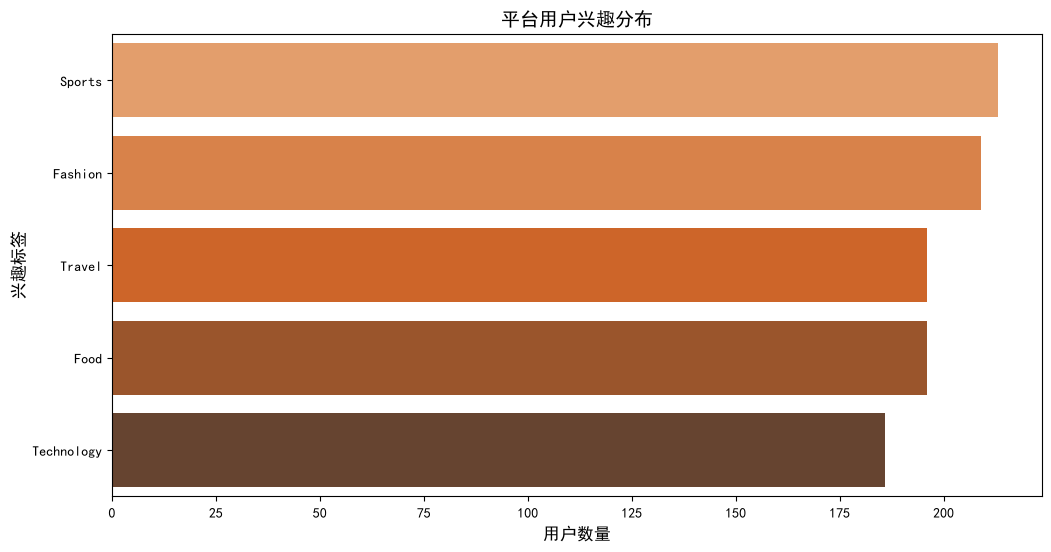

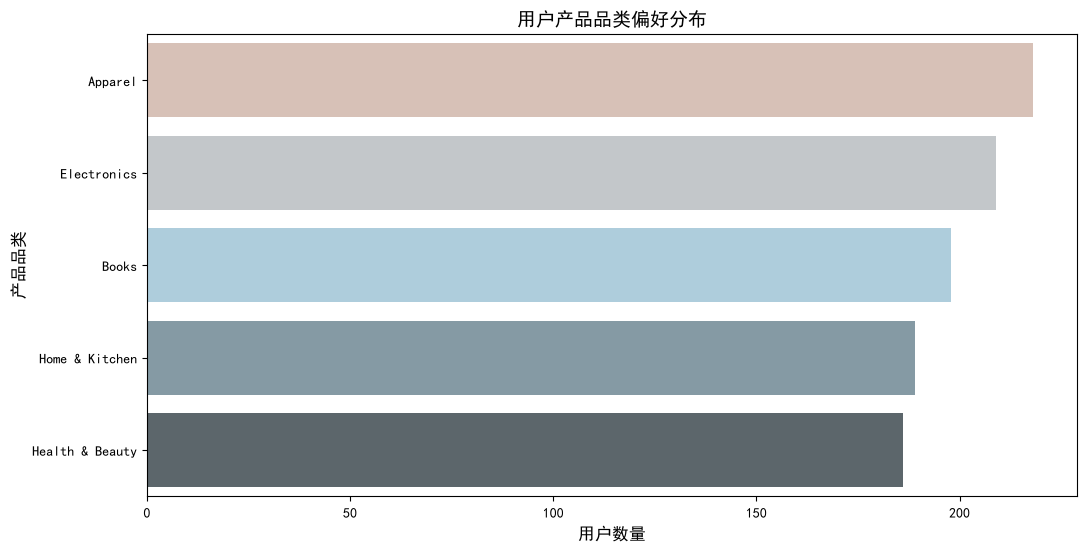

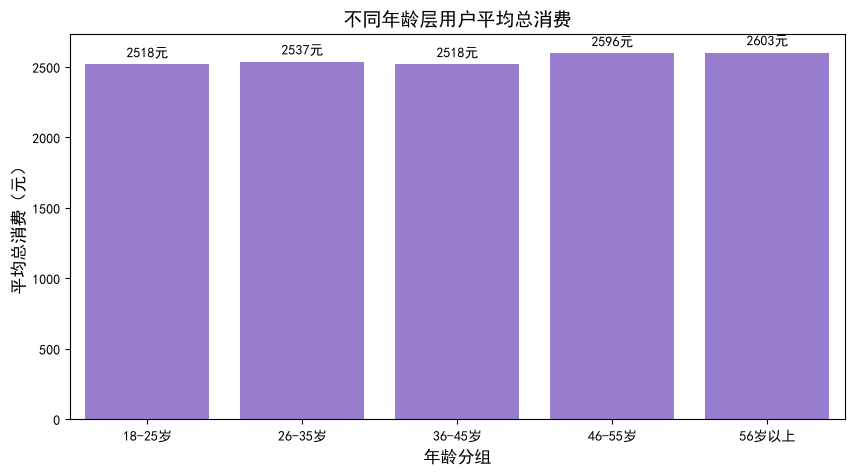

In [81]:
# 1. 性别分布
plt.figure(figsize=(8, 5))
gender_count = df['Gender'].value_counts()
sns.barplot(x=gender_count.index, y=gender_count.values, hue=gender_count.index, palette='Blues_d', legend=False)
plt.title('平台用户性别分布', fontsize=14)
plt.xlabel('性别', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
# 给柱子加数值标签
for i, v in enumerate(gender_count.values):
    plt.text(i, v+5, str(v), ha='center', fontsize=10)
plt.savefig('用户性别分布.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 年龄分层分布（把年龄分组，更有业务意义）
df['Age_Group'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 70], labels=['18-25岁', '26-35岁', '36-45岁', '46-55岁', '56岁以上'])
plt.figure(figsize=(10, 5))
age_count = df['Age_Group'].value_counts().sort_index()
sns.barplot(x=age_count.index, y=age_count.values, color='mediumpurple')
plt.title('平台用户年龄分层分布', fontsize=14)
plt.xlabel('年龄分组', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
for i, v in enumerate(age_count.values):
    plt.text(i, v + 5, str(v), ha='center', fontsize=10)
plt.savefig('用户年龄分布.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. 用户地域分布
plt.figure(figsize=(8, 5))
location_count = df['Location'].value_counts()
sns.barplot(x=location_count.index, y=location_count.values, hue=location_count.index, palette='Greens_d', legend=False)
plt.title('平台用户地域分布', fontsize=14)
plt.xlabel('居住地', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
for i, v in enumerate(location_count.values):
    plt.text(i, v+5, str(v), ha='center', fontsize=10)
plt.savefig('用户地域分布.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 用户兴趣分布
plt.figure(figsize=(12, 6))
interest_count = df['Interests'].value_counts()
sns.barplot(x=interest_count.values, y=interest_count.index, hue=interest_count.index, palette='Oranges_d', legend=False)
plt.title('平台用户兴趣分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('兴趣标签', fontsize=12)
plt.savefig('用户兴趣分布.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. 产品品类偏好分布
plt.figure(figsize=(12, 6))
category_count = df['Product_Category_Preference'].value_counts()
sns.barplot(x=category_count.values, y=category_count.index, hue=category_count.index, palette='RdBu_d', legend=False)
plt.title('用户产品品类偏好分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('产品品类', fontsize=12)
plt.savefig('品类偏好分布.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. 不同年龄层的总消费均值对比
plt.figure(figsize=(10, 5))
age_spending = df.groupby('Age_Group')['Total_Spending'].mean().sort_index()
sns.barplot(x=age_spending.index, y=age_spending.values, color='mediumpurple')
plt.title('不同年龄层用户平均总消费', fontsize=14)
plt.xlabel('年龄分组', fontsize=12)
plt.ylabel('平均总消费（元）', fontsize=12)
for i, v in enumerate(age_spending.values):
    plt.text(i, v+50, f'{int(v)}元', ha='center', fontsize=10)
plt.savefig('年龄层消费对比.png', dpi=300, bbox_inches='tight')
plt.show()

## 用户行为深度分析
用户行为深度分析聚焦用户动态使用行为，挖掘活跃度、流失、粘性相关特征，识别业务问题，为精细化运营和用户价值分层提供依据。

(1) 从用户上次登录距今天数分布可得出核心洞察:
平台未登录用户集中在 15-25 天区间，峰值出现在 20 天左右。
15 天内有登录行为的活跃用户占据一定规模，但 15‑30 天未登录的流失预警用户、30 天以上长期未登录流失用户体量较大，
近四分之一用户存在流失风险，用户留存与用户召回工作亟待推进。

(2) 通过箱线图对比邮件订阅用户与非订阅用户的网站停留时长，得出核心结论:
邮件订阅用户网站停留时长中位数约 300 分钟，与非订阅用户接近，
但订阅用户的停留时长上四分位数与最大值整体优于非订阅用户。
业务洞察：邮件订阅对提升用户平台粘性存在正向效果，是低成本改善留存的重要抓手，可着力提高平台邮件订阅转化率。 

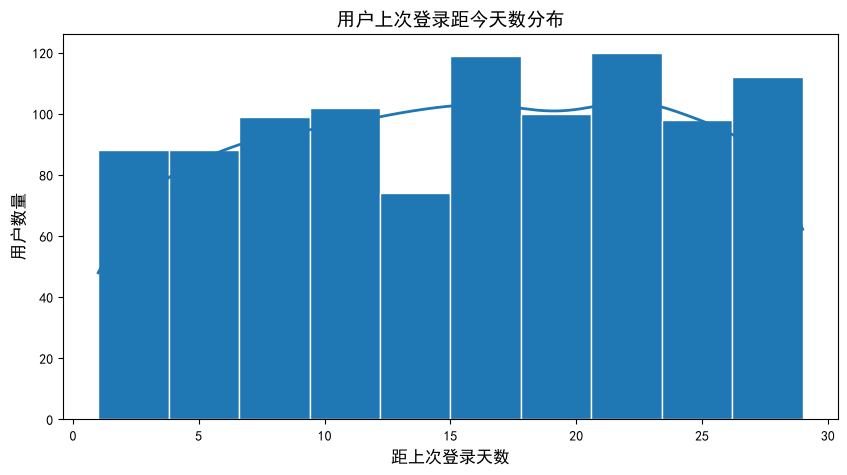

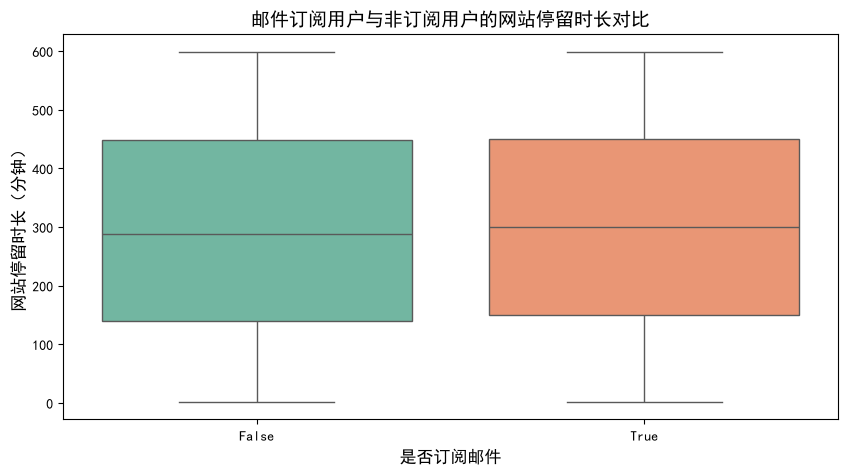

In [37]:
# 1. 上次登录天数分布（判断用户活跃/流失情况）
# 提取数据并去除空值
data = df['Last_Login_Days_Ago'].dropna()
plt.figure(figsize=(10, 5))
# 绘制直方图，和原需求效果完全一致
n, bins, patches = plt.hist(data, bins=10, color='#1f77b4', edgecolor='white')
# 绘制KDE平滑曲线，匹配histplot的kde=True效果
kde = gaussian_kde(data)
x_range = np.linspace(bins.min(), bins.max(), 1000)
# 缩放KDE曲线，匹配直方图的用户数量刻度
plt.plot(x_range, kde(x_range) * len(data) * np.diff(bins)[0], color='#1f77b4', linewidth=2)
plt.title('用户上次登录距今天数分布', fontsize=14)
plt.xlabel('距上次登录天数', fontsize=12)
plt.ylabel('用户数量', fontsize=12)
plt.show()

# 2. 订阅用户vs非订阅用户的活跃度对比
plt.figure(figsize=(10, 5))
sns.boxplot(x='Newsletter_Subscription', y='Time_Spent_on_Site_Minutes', data=df, hue='Newsletter_Subscription', palette='Set2', legend=False)
plt.title('邮件订阅用户与非订阅用户的网站停留时长对比', fontsize=14)
plt.xlabel('是否订阅邮件', fontsize=12)
plt.ylabel('网站停留时长（分钟）', fontsize=12)
plt.savefig('订阅用户活跃度对比.png', dpi=300, bbox_inches='tight')
plt.show()

## RFM用户价值分层
基于电商行业经典的 RFM 模型，完成用户价值分群，解决平台「用户价值不清晰、运营资源错配」的核心痛点。

基于RFM 模型（最近消费、消费频率、消费金额）把全部用户划分 8 个群体，条形长度代表对应分层的用户数量。平台低价值用户体量最大，高价值核心用户占比最小；同时存在规模可观的流失、待召回用户群体，用户结构呈现 “金字塔” 特征。


用户价值分层结果：
User_Level
低价值用户      210
新用户        152
需召回用户      145
流失高价值用户    145
流失预警用户     100
潜力用户        93
深耕用户        93
高价值用户       62
Name: count, dtype: int64


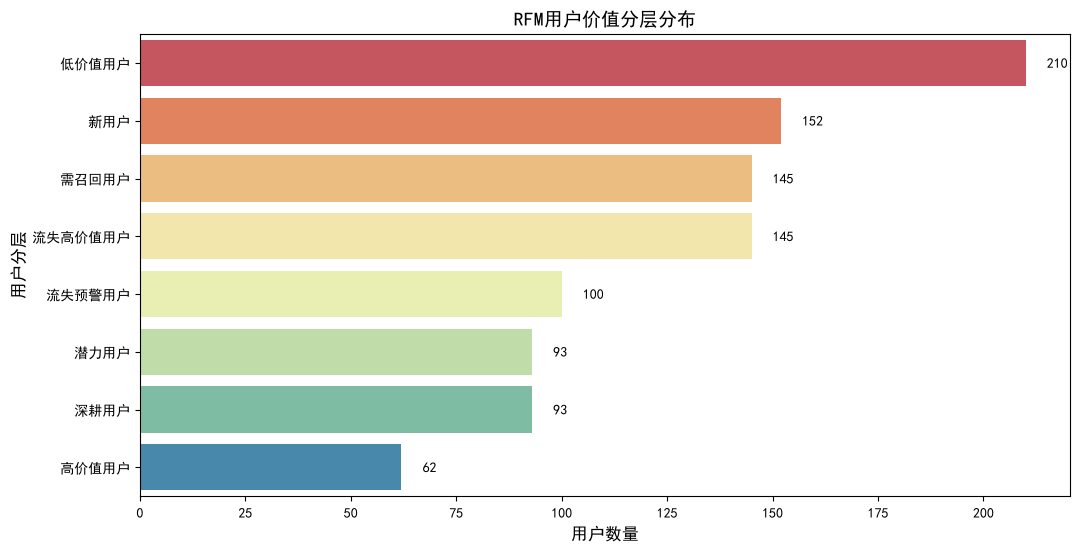

In [47]:
# 1. 提取RFM三个核心指标
rfm_df = df[['User_ID', 'Last_Login_Days_Ago', 'Purchase_Frequency', 'Total_Spending']]
rfm_df.columns = ['User_ID', 'R', 'F', 'M']

# 2. 给RFM指标打分（1-5分，5分为最优）
# R值：越小越好，所以倒序打分
rfm_df['R_Score'] = pd.qcut(rfm_df['R'].rank(method='first'), q=5, labels=[5,4,3,2,1])
# F值：越大越好，正序打分
rfm_df['F_Score'] = pd.qcut(rfm_df['F'].rank(method='first'), q=5, labels=[1,2,3,4,5])
# M值：越大越好，正序打分
rfm_df['M_Score'] = pd.qcut(rfm_df['M'].rank(method='first'), q=5, labels=[1,2,3,4,5])

# 3. 拼接RFM得分，生成用户标签
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)

# 4. 用户价值分层（经典8分法，简化版，容易理解和讲解）
def user_level(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >=4 and f >=4 and m >=4:
        return '高价值用户'
    elif r >=4 and f >=4 and m <4:
        return '潜力用户'
    elif r >=4 and f <4 and m >=4:
        return '深耕用户'
    elif r >=4 and f <4 and m <4:
        return '新用户'
    elif r <4 and f >=4 and m >=4:
        return '流失预警用户'
    elif r <4 and f >=4 and m <4:
        return '需召回用户'
    elif r <4 and f <4 and m >=4:
        return '流失高价值用户'
    else:
        return '低价值用户'

rfm_df['User_Level'] = rfm_df.apply(user_level, axis=1)

# 5. 查看各用户群体数量分布
level_count = rfm_df['User_Level'].value_counts()
print("\n用户价值分层结果：")
print(level_count)

# 6. 可视化用户分层结果
plt.figure(figsize=(12, 6))
sns.barplot(x=level_count.values, y=level_count.index, hue=level_count.index, palette='Spectral', legend=False)
plt.title('RFM用户价值分层分布', fontsize=14)
plt.xlabel('用户数量', fontsize=12)
plt.ylabel('用户分层', fontsize=12)
for i, v in enumerate(level_count.values):
    plt.text(v+5, i, str(v), va='center', fontsize=10)
plt.savefig('RFM用户分层.png', dpi=300, bbox_inches='tight')
plt.show()

# 7. 把分层结果合并回原数据，方便后续分析
df = pd.merge(df, rfm_df[['User_ID', 'User_Level']], on='User_ID', how='left')

## 用户消费行为影响因素分析
通过皮尔逊相关系数分析，挖掘影响用户总消费的核心指标，定位平台 GMV 增长的核心抓手

从皮尔逊相关系数热力图可以观测到，各指标之间大多相关性较弱，其中平均订单价值与用户总消费的正向关联程度最高，是影响用户消费总额的主要因素；上次登录间隔天数、购买频率仅存在微弱正向关系，对消费的拉动作用有限，而年龄、收入、网站停留时长等指标和总消费几乎不存在相关关系，说明平台消费潜力分布在全体用户，不存在明显的年龄、收入人群壁垒。

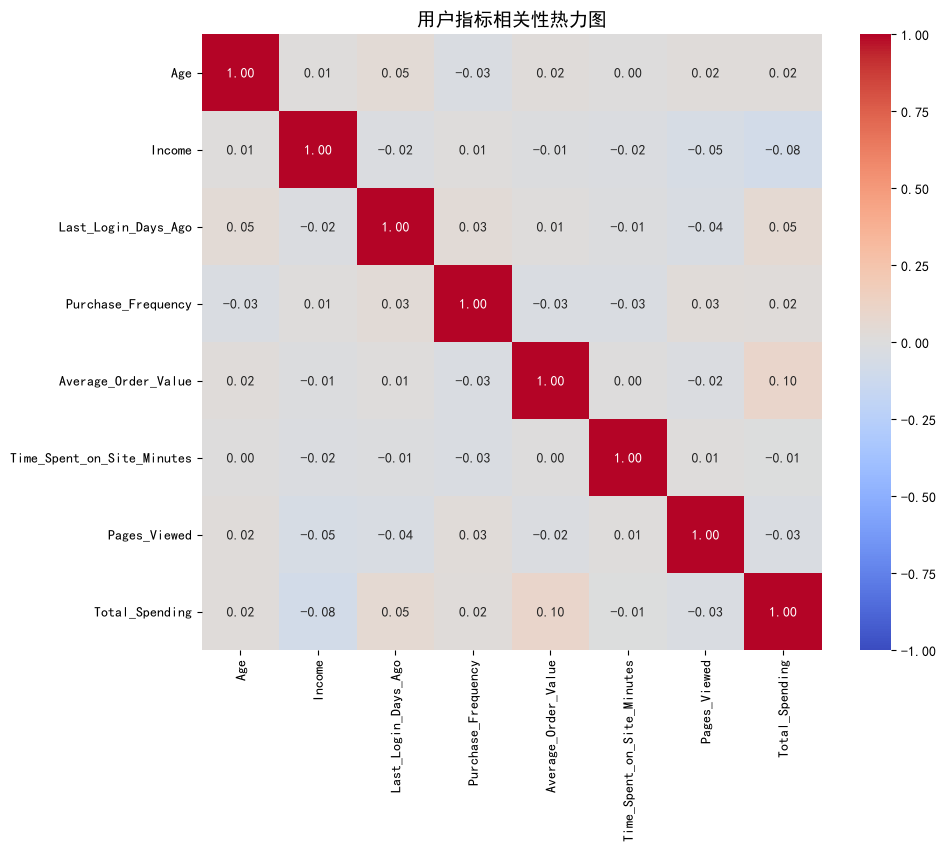


和用户总消费相关性TOP5指标：
Total_Spending                1.000000
Average_Order_Value           0.096705
Last_Login_Days_Ago           0.054688
Purchase_Frequency            0.022206
Age                           0.018262
Time_Spent_on_Site_Minutes   -0.006380
Name: Total_Spending, dtype: float64


In [72]:
# 筛选数值型字段，计算和总消费的相关性
num_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
            'Average_Order_Value', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed', 'Total_Spending']
corr_df = df[num_cols].corr()

# 可视化相关性热力图
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('用户指标相关性热力图', fontsize=14)
plt.savefig('相关性热力图.png', dpi=300, bbox_inches='tight')
plt.show()

# 输出和总消费相关性最高的指标
print("\n和用户总消费相关性TOP5指标：")
print(corr_df['Total_Spending'].sort_values(ascending=False).head(6))